# OBJECTIVE : 
* TO ANALYSE TITANIC PASSENGER DATA AND IDENTIFY FACTORS AFFECTING SURVIVAL

* THE VARIOUS TOOLS USED IN THIS PROJECT :
PYTHON , PANDAS , MATPLOTLIB , SEABORN

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Hatim Khan\Downloads\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# RETREIVING THE BASIC INFORMATION FROM THE DATA FOR BETTER UNDERSTANDING

In [4]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# CLEANING THE DATA NOW : 

In [11]:
df["Age"].fillna(df["Age"].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [9]:
df["Age"].isnull().sum()

np.int64(0)

In [12]:
df["Embarked"].fillna(df["Embarked"].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [11]:
df["Embarked"].isnull().sum()

np.int64(0)

# ANALYSE THE SURVIVAL PATTERNS 
# SURVIVAL BY GENDER

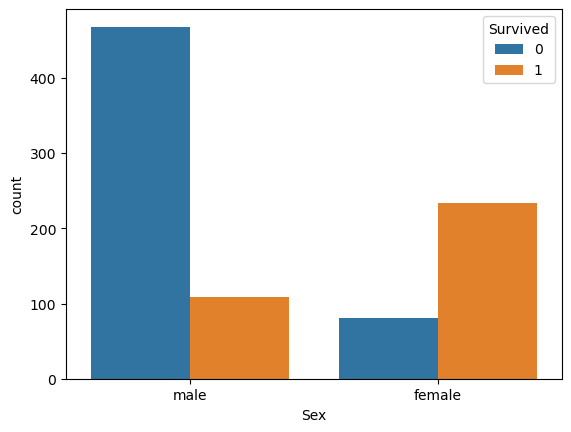

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [12]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.show()
df.groupby("Sex")["Survived"].mean()

* FEMALES SURVIVED MORE THAN MALES

# SURVIVAL BY PASSENGER CLASS

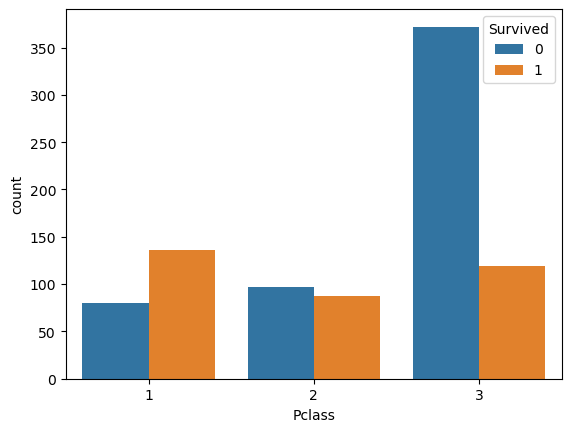

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [13]:
sns.countplot(x ="Pclass", hue ="Survived", data =df)
plt.show()
df.groupby("Pclass")["Survived"].mean()

* THE HIGHER CLASS HAS HIGHER RATE OF SURVIVAL

# SURVIVAL BY AGE

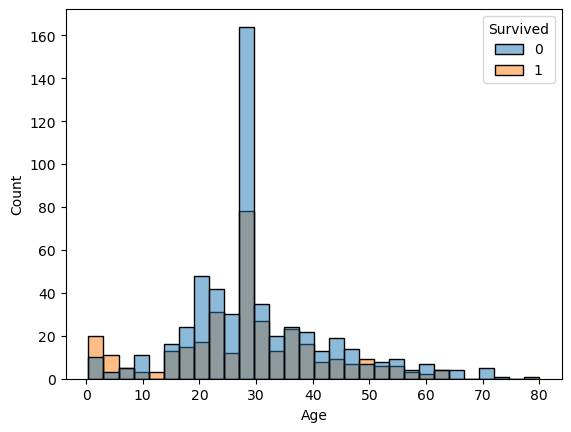

In [14]:
sns.histplot(data = df, x = "Age", hue = "Survived", bins = 30)
plt.show()

# SURVIVAL BY GENDER

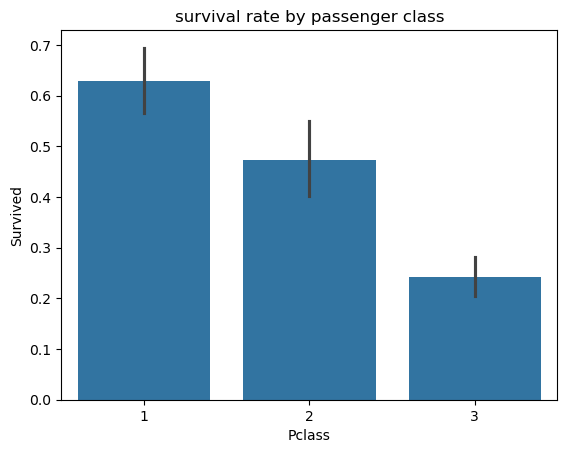

In [17]:
sns.barplot(x = "Pclass", y = "Survived", data = df)
plt.title("survival rate by passenger class")
plt.show()

* CHILDREN SURVIVED MORE THAN ANY OTHER AGE GROUP

# SO THE TOTAL ESTIMATION OF THIS PROJECT IS THIS : 

* FEMALES HAD HISGHEST SURVIVAL RATE THAN MALE
* FIRST CLASS PASSENGERS SURVIVED MORE THAN THE OTHER ONE
* CHILDREN HAD BETTER SURVIVAL CHANCES THAN ADULTS

# CONCLUSION : 
* PASSENGER GENDER , CLASS AND AGE STRONGLY INFLUENCED SURVIVAL CHANCES